<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">


# Sistema de detection the SPAM

We want to implement a system that is able to automatically detect whether a web page contains spam or not based on its URL.
</div>

In [1]:
%pip install nltk --quiet

# CONFIGURACIÓN DEL ENTORNO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Librerias to manage filesimport os
from pathlib import Path
import os

#Libraries to manage images
from PIL import Image

#Libraries for machine learning
from sklearn.svm import SVC
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from pickle import dump
from pathlib import Path

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")

Note: you may need to restart the kernel to use updated packages.
✓ ¡Librerías importadas exitosamente!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 1: Loading the dataset
The dataset can be found in this project folder under the name url_spam.csv. It contains two columns: url and label. The url column contains the URL of the web page, and the label column contains the label of the web page, which can be either 0 (not spam) or 1 (spam).

</div>

In [2]:
# Load preprocessed data
df = pd.read_csv('../data/raw/url_spam.csv')
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nLabel distribution:\n{df['is_spam'].value_counts()}")

                                                 url  is_spam
0  https://briefingday.us8.list-manage.com/unsubs...     True
1                             https://www.hvper.com/     True
2                 https://briefingday.com/m/v4n3i4f3     True
3   https://briefingday.com/n/20200618/m#commentform    False
4                        https://briefingday.com/fan     True
5  https://www.brookings.edu/interactives/reopeni...    False
6  https://www.reuters.com/investigates/special-r...    False
7  https://www.theatlantic.com/magazine/archive/2...    False
8  https://www.vox.com/2020/6/17/21294680/john-bo...    False
9  https://www.theguardian.com/travel/2020/jun/18...    False

Shape: (2999, 2)

Column types:
url        object
is_spam      bool
dtype: object

Label distribution:
is_spam
False    2303
True      696
Name: count, dtype: int64


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 2: Preprocess the links
Use what we have seen in this module to transform the data to make it compatible with the model we want to train. Segment the URLs into parts according to their punctuation marks, remove stopwords, lemmatize, and so on.

Make sure to conveniently split the dataset into train and test as we have seen in previous lessons.
</div>    

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 1. Convert is_spam label to numeric (True -> 1, False -> 0)
df['is_spam'] = df['is_spam'].astype(int)
print(f"Label distribution after encoding:\n{df['is_spam'].value_counts()}\n")

# 2. Tokenize URLs by splitting on punctuation marks (/ . - _ = ? & # : @)
def tokenize_url(url):
    # Remove the protocol (http:// or https://)
    url = re.sub(r'https?://', '', url)
    # Split on common URL punctuation marks
    tokens = re.split(r'[/.\-_=?&#:@%+~]', url)
    # Remove empty strings and purely numeric tokens
    tokens = [t.lower() for t in tokens if t and not t.isdigit()]
    return tokens

df['tokens'] = df['url'].apply(tokenize_url)
print("Sample tokens (first 3 URLs):")
for i in range(3):
    print(f"  {df['url'].iloc[i][:60]}... -> {df['tokens'].iloc[i]}")

# 3. Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)

# 4. Lemmatize
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_tokens)

# 5. Join tokens back into a single string for TF-IDF vectorization
df['processed_url'] = df['tokens'].apply(lambda x: ' '.join(x))

print(f"\nSample processed URLs:")
print(df[['url', 'processed_url']].head())

# 6. Vectorize with TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_url'])
y = df['is_spam']

print(f"\nTF-IDF matrix shape: {X.shape}")
print(f"Top 20 features: {tfidf.get_feature_names_out()[:20]}")

# 7. Train/test split (80/20, stratified, random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Train label distribution:\n{y_train.value_counts()}")
print(f"Test label distribution:\n{y_test.value_counts()}")

Label distribution after encoding:
is_spam
0    2303
1     696
Name: count, dtype: int64

Sample tokens (first 3 URLs):
  https://briefingday.us8.list-manage.com/unsubscribe... -> ['briefingday', 'us8', 'list', 'manage', 'com', 'unsubscribe']
  https://www.hvper.com/... -> ['www', 'hvper', 'com']
  https://briefingday.com/m/v4n3i4f3... -> ['briefingday', 'com', 'm', 'v4n3i4f3']

Sample processed URLs:
                                                 url  \
0  https://briefingday.us8.list-manage.com/unsubs...   
1                             https://www.hvper.com/   
2                 https://briefingday.com/m/v4n3i4f3   
3   https://briefingday.com/n/20200618/m#commentform   
4                        https://briefingday.com/fan   

                                 processed_url  
0  briefingday us8 list manage com unsubscribe  
1                                www hvper com  
2                     briefingday com v4n3i4f3  
3                briefingday com n commentform  
4            

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 3: Build an SVM
Start solving the problem by implementing an SVM with the default parameters. Train it and analyze its results.
</div>

SVM default parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Training accuracy: 0.9850
Test accuracy:     0.9583

Classification Report (Test Set):
              precision    recall  f1-score   support

    Not Spam       0.96      0.99      0.97       461
        Spam       0.96      0.86      0.90       139

    accuracy                           0.96       600
   macro avg       0.96      0.92      0.94       600
weighted avg       0.96      0.96      0.96       600



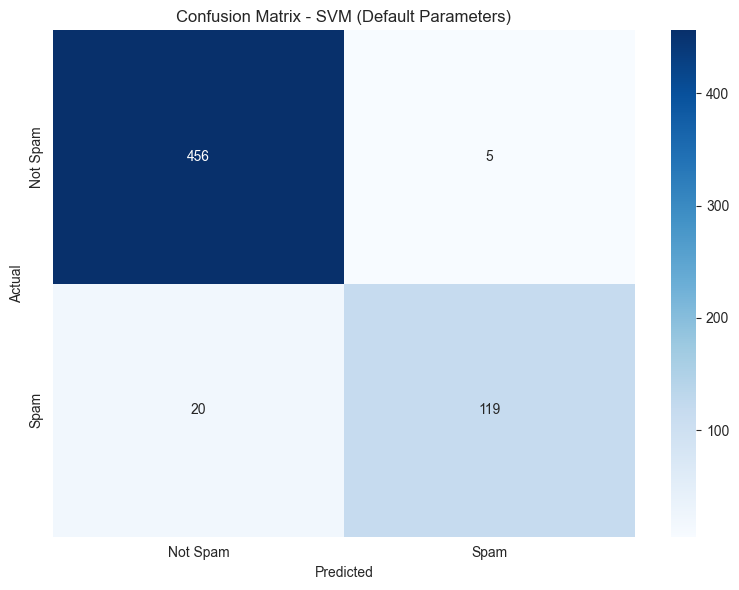


True Negatives:  456
False Positives: 5
False Negatives: 20
True Positives:  119


In [4]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Train an SVM with default parameters
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

print(f"SVM default parameters: {svm_model.get_params()}\n")

# 2. Predictions
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

# 3. Accuracy
print(f"Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test accuracy:     {accuracy_score(y_test, y_pred_test):.4f}\n")

# 4. Classification report (test set)
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['Not Spam', 'Spam']))

# 5. Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM (Default Parameters)')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 4: Optimize the previous model
After training the SVM, optimize its hyperparameters using a grid search or a random search.
</div>

Starting Grid Search with 5-fold cross-validation...
Parameter grid: {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
Total combinations: 12 x 5 folds = 60 fits

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-score: 0.9120

All combinations ranked by F1-score:
 param_C param_kernel param_gamma  mean_train_score  mean_test_score  rank_test_score
    10.0          rbf       scale          0.989269         0.911963                1
    10.0       linear       scale          0.988158         0.894162                2
    10.0       linear        auto          0.988158         0.894162                2
     1.0          rbf       scale          0.967577         0.890672                4
     1.0       linear       scale          0.961592         0.882203                5
     1.0       linear        auto          0.961592         0.882203                5
     0.1       linear

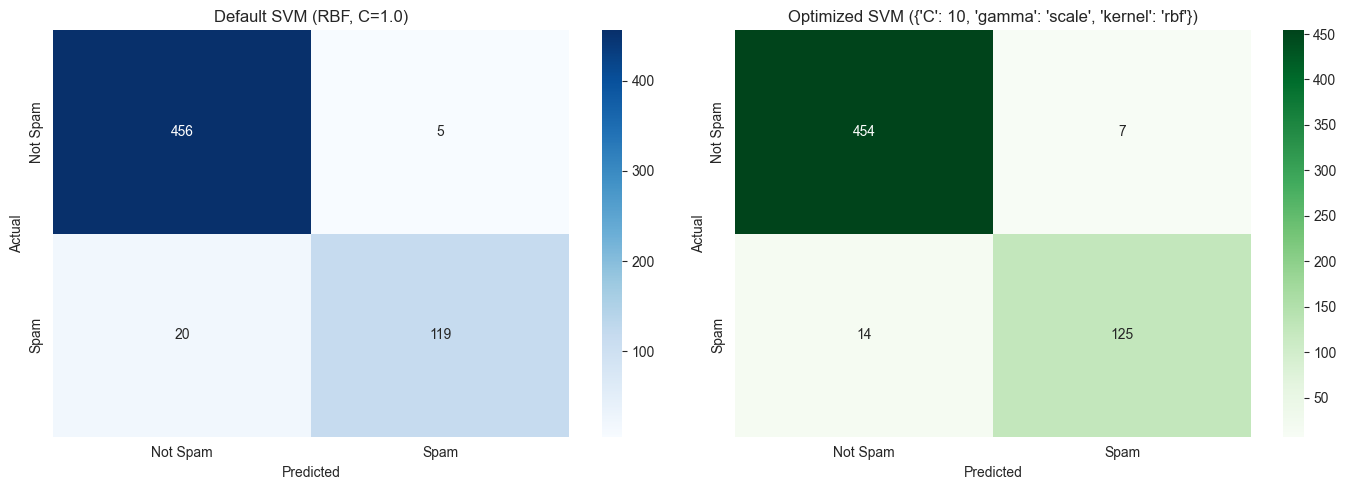


Accuracy improvement: 0.9583 -> 0.9650 (+0.67%)


In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

print("Starting Grid Search with 5-fold cross-validation...")
print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {3 * 2 * 2} x 5 folds = {3 * 2 * 2 * 5} fits\n")

# Grid Search with cross-validation
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

# Best parameters and score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

# Results summary for all combinations
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_C', 'param_kernel', 'param_gamma', 'mean_train_score', 'mean_test_score', 'rank_test_score']
print(f"\nAll combinations ranked by F1-score:")
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# Evaluate the optimized model on the test set
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)

print(f"\n{'='*50}")
print("OPTIMIZED MODEL - Test Set Results")
print(f"{'='*50}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_opt, target_names=['Not Spam', 'Spam']))

# Confusion matrix comparison
cm_opt = confusion_matrix(y_test, y_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default SVM
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Default SVM (RBF, C=1.0)')

# Optimized SVM
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f"Optimized SVM ({grid_search.best_params_})")

plt.tight_layout()
plt.show()

# Improvement summary
acc_default = accuracy_score(y_test, y_pred_test)
acc_optimized = accuracy_score(y_test, y_pred_opt)
print(f"\nAccuracy improvement: {acc_default:.4f} -> {acc_optimized:.4f} ({(acc_optimized - acc_default)*100:+.2f}%)")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 5: Save the model
Store the model in the corresponding folder.
</div>

In [6]:
from pickle import dump
from pathlib import Path

# Create the output directory if it doesn't exist
model_dir = Path('../models')
model_dir.mkdir(parents=True, exist_ok=True)

# Save the optimized SVM model
with open(model_dir / 'svm_url_spam_model.pkl', 'wb') as f:
    dump(best_model, f)

# Save the TF-IDF vectorizer (needed for predictions on new data)
with open(model_dir / 'tfidf_url_spam_vectorizer.pkl', 'wb') as f:
    dump(tfidf, f)

print(f"✓ Optimized SVM model saved to: {model_dir / 'svm_url_spam_model.pkl'}")
print(f"✓ TF-IDF vectorizer saved to:   {model_dir / 'tfidf_url_spam_vectorizer.pkl'}")
print(f"\nModel parameters: {best_model.get_params()}")

✓ Optimized SVM model saved to: ../models/svm_url_spam_model.pkl
✓ TF-IDF vectorizer saved to:   ../models/tfidf_url_spam_vectorizer.pkl

Model parameters: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
